In [1]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.append(homepath)

%load_ext autoreload 
%autoreload 2
%matplotlib inline


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from meteor import rsmap
from meteor.utils import cut_resolution

from meteor.diffmaps import compute_difference_map, max_negentropy_kweighted_difference_map
from meteor.tv import tv_denoise_difference_map
from meteor.validate import map_negentropy

In [3]:
# from photolyase import *
from photolyase import get_exp_structure_factors, calculate_dog_filter_mask_v2, ccp4_to_mask
from compare_conds import get_intersect_and_angle
from photolyase import get_hists, plot_hists, find_wasserstein_dip
from plotting3d import slice_3d, add_fit
from meteorize import *
# from output_eval import panels_3d
from systematic_plots import setup_logger


In [4]:
logger = setup_logger(logging.INFO)


In [5]:
folderloc =  homepath+'../photolyase_share_reviewers/'
dataloc_dark  = folderloc + '1_superdark/superdark_deposit.mtz'
pdbloc_dark  = folderloc + '1_superdark/superdark_deposit.pdb'
changing_bit = "6_10ns/10ns"
changing_bit = "2_3ps/3ps"
changing_bit = "3_300ps/300ps"
changing_bit = "7_30ns/30ns"
dataloc_light = folderloc + changing_bit + "_deposit.mtz"
pdbloc_light  = folderloc + changing_bit + '_deposit.pdb'


mask_loc_sphere = homepath+"../photolyase_masks/photolyase_TT_chainA_spherical_mask.ccp4"
mask_loc_handcraft = homepath+"../photolyase_masks/photolyase_chainA_spherical_masks.ccp4"
hs_limit = 2.4 
map_sampling = 3




In [6]:
ds_light = rs.read_mtz(dataloc_light)
ds_dark = rs.read_mtz(dataloc_dark)

ds_dark = cut_resolution(ds_dark,high_resolution_limit=hs_limit)
ds_light = cut_resolution(ds_light,high_resolution_limit=hs_limit)

ds_light

IMEAN       SIGIMEAN           F       SIGF       KFEXTR  \
H  K L                                                                   
0  0 2          NaN            NaN         NaN        NaN          NaN   
     4          NaN            NaN         NaN        NaN          NaN   
     6   563041.625  124030.234375  733.373047  87.899185  3107.084473   
     7 -1661.612183    1027.905151    12.38824   8.876429          NaN   
     8  -470.827209     346.035034    7.571723   5.376757    58.114021   
...             ...            ...         ...        ...          ...   
29 5 5          NaN            NaN         NaN        NaN          NaN   
   6 0          NaN            NaN         NaN        NaN          NaN   
     1          NaN            NaN         NaN        NaN          NaN   
     2          NaN            NaN         NaN        NaN          NaN   
     3          NaN            NaN         NaN        NaN          NaN   

        SIGKFEXTR  R-free-flags      F-model  PHIF-model      2FOFCWT  \
H  K L                                                                  
0  0 2        NaN           NaN          NaN         NaN  6650.478516   
     4        NaN            14          NaN         NaN  1927.483765   
     6  16.496628             6  3358.235596         0.0  3301.962158   
     7        NaN           NaN          NaN         NaN          NaN   
     8  40.554333            17   168.217529         0.0     2.425961   
...           ...           ...          ...         ...          ...   
29 5 5        NaN             3          NaN         NaN          NaN   
   6 0        NaN            10          NaN         NaN          NaN   
     1        NaN             8          NaN         NaN          NaN   
     2        NaN            19          NaN         NaN          NaN   
     3        NaN            13          NaN         NaN          NaN   

        PH2FOFCWT  2FOFCWT_no_fill  PH2FOFCWT_no_fill      FOFCWT  PHFOFCWT  
H  K L                                                                       
0  0 2        0.0              NaN                NaN         NaN       NaN  
     4        0.0              NaN                NaN         NaN       NaN  
     6        0.0      3301.962158                0.0  752.040527       0.0  
     7        NaN              NaN                NaN         NaN       NaN  
     8        0.0         2.425961                0.0  124.879761     180.0  
...           ...              ...                ...         ...       ...  
29 5 5        NaN              NaN                NaN         NaN       NaN  
   6 0        NaN              NaN                NaN         NaN       NaN  
     1        NaN              NaN                NaN         NaN       NaN  
     2        NaN              NaN                NaN         NaN       NaN  
     3        NaN              NaN                NaN         NaN       NaN  

[56146 rows x 15 columns]

In [7]:
map_dark, map_light = get_scaled_maps(ds_dark, ds_light)



2025-07-28 16:20:35,215: INFO: Dark columns: Index(['I-obs', 'SIGI-obs', 'R-free-flags', 'F-obs-filtered',
                                     'SIGF-obs-filtered', 'F-model', 'PHIF-model', '2FOFCWT', 'PH2FOFCWT',
                                     '2FOFCWT_no_fill', 'PH2FOFCWT_no_fill', 'FOFCWT', 'PHFOFCWT'],
                                    dtype='object') (meteorize.py:47)
2025-07-28 16:20:35,216: INFO: Dark amplitude column: F-obs-filtered (meteorize.py:48)
2025-07-28 16:20:35,225: INFO: Scaled dataset columns: Index(['F_dark', 'SIGF_dark', 'F_light', 'SIGF_light'], dtype='object') (meteorize.py:62)
2025-07-28 16:20:35,237: INFO: Running scaleit, see tmp/launch_scaleit.sh (generate_objects.py:477)
./tmp/launch_scaleit.sh: line 2: scaleit: command not found


In [8]:
from photolyase import loading_diffmaps
diffmaps, diffmap_config = loading_diffmaps(
    map_dark=map_dark,
    map_light=map_light,
    changing_bit=changing_bit,
    map_sampling=map_sampling,
)

key = "tv"
diffmap = diffmaps[key]


Reading from photolyase30ns.mtz


In [9]:
pos_blobs, neg_blobs = find_largest_blobs(diffmap, map_sampling=map_sampling,
                                          threshold=0.5, minimum_size=3)
pos_blobs2, neg_blobs2 = find_largest_blobs2(diffmap=diffmap, map_sampling=map_sampling,
                                              threshold=0.5, minimum_size=3)

2025-07-28 16:23:30,302: INFO: Running Many NegSum - Best Guess (<string>:48)
2025-07-28 16:23:30,399: INFO: Number of Masks: 15 (systematic_plots.py:242)
2025-07-28 16:23:30,400: WARNING: Unresolved ToDos in many_negsum (meteorize.py:162)


Minimum Threshold:  0.5


2025-07-28 16:23:32,220: INFO: Intersection Average 2: 25.05 ± 10.46 (meteorize.py:222)
2025-07-28 16:23:32,220: INFO: Intersection Average Inverse: 0.09 ± 0.04 (meteorize.py:227)
2025-07-28 16:23:32,331: INFO: Number of Masks: 15 (systematic_plots.py:242)
2025-07-28 16:23:32,332: WARNING: Unresolved ToDos in many_negsum (meteorize.py:162)
2025-07-28 16:23:34,135: INFO: Intersection Average 2: 26.40 ± 11.47 (meteorize.py:222)
2025-07-28 16:23:34,135: INFO: Intersection Average Inverse: 0.09 ± 0.04 (meteorize.py:227)
2025-07-28 16:23:34,242: INFO: Number of Masks: 10 (systematic_plots.py:242)
2025-07-28 16:23:34,242: WARNING: Unresolved ToDos in many_negsum (meteorize.py:162)
2025-07-28 16:23:35,934: INFO: Intersection Average 2: 26.33 ± 12.36 (meteorize.py:222)
2025-07-28 16:23:35,935: INFO: Intersection Average Inverse: 0.09 ± 0.04 (meteorize.py:227)
2025-07-28 16:23:36,037: INFO: Number of Masks: 10 (systematic_plots.py:242)
2025-07-28 16:23:36,037: WARNING: Unresolved ToDos in many_

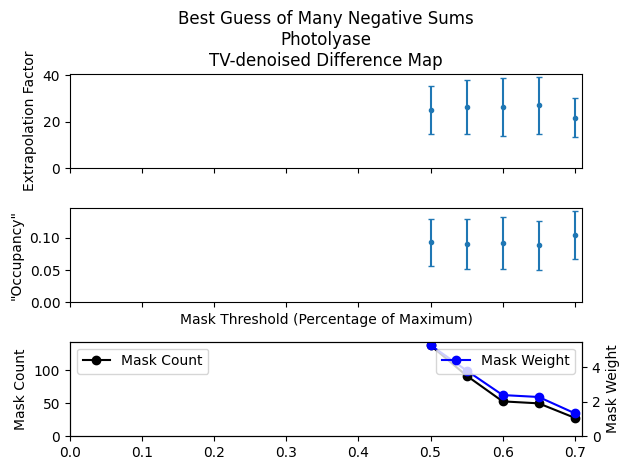

2025-07-28 16:23:39,825: INFO: Running Many NegSum - Best Guess (<string>:54)
2025-07-28 16:23:40,001: WARNING: Unresolved ToDos in many_negsum (meteorize.py:162)
2025-07-28 16:23:44,580: INFO: Intersection Average 2: 34.43 ± 15.99 (meteorize.py:222)
2025-07-28 16:23:44,580: INFO: Intersection Average Inverse: 0.07 ± 0.03 (meteorize.py:227)
2025-07-28 16:23:44,776: WARNING: Unresolved ToDos in many_negsum (meteorize.py:162)
2025-07-28 16:23:46,675: INFO: Intersection Average 2: 25.05 ± 10.46 (meteorize.py:222)
2025-07-28 16:23:46,676: INFO: Intersection Average Inverse: 0.09 ± 0.04 (meteorize.py:227)
2025-07-28 16:23:46,789: WARNING: Unresolved ToDos in many_negsum (meteorize.py:162)
2025-07-28 16:23:48,429: INFO: Intersection Average 2: 21.83 ± 8.54 (meteorize.py:222)
2025-07-28 16:23:48,429: INFO: Intersection Average Inverse: 0.10 ± 0.04 (meteorize.py:227)


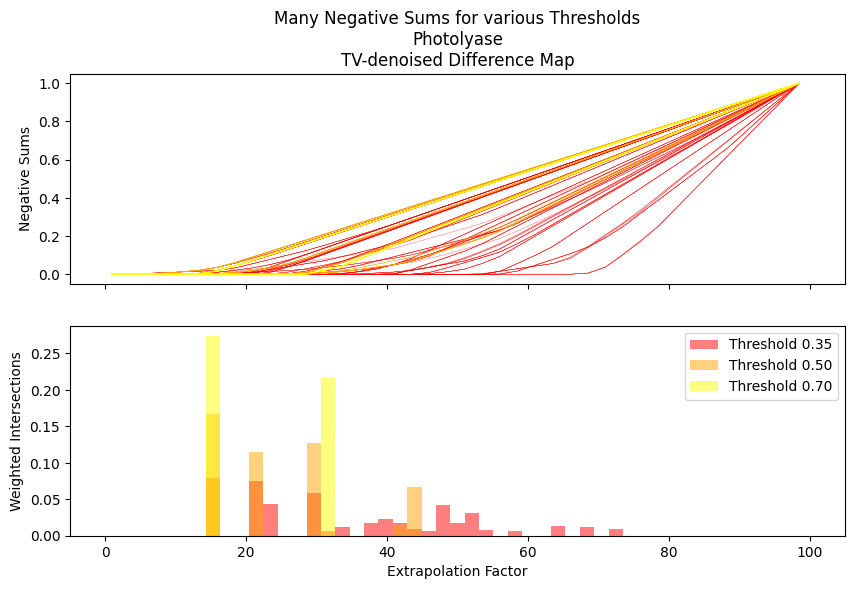

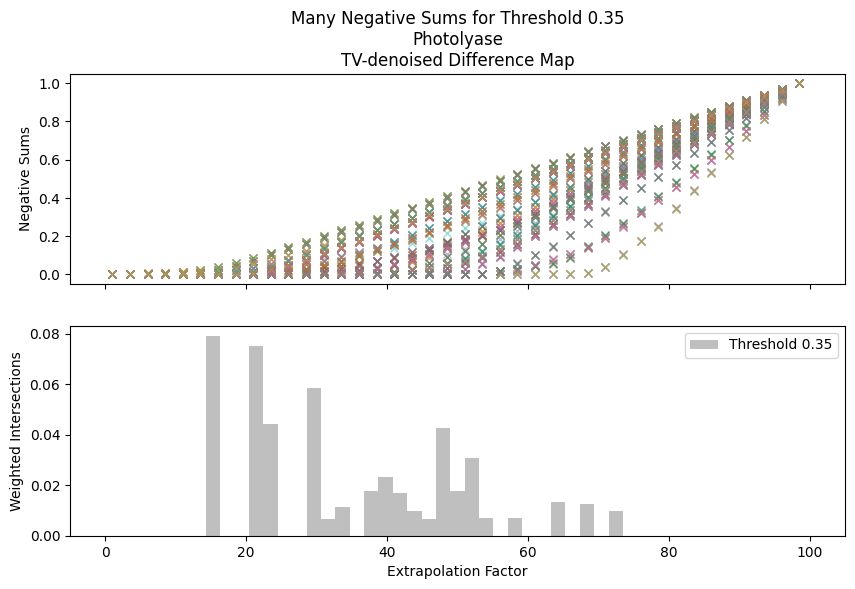

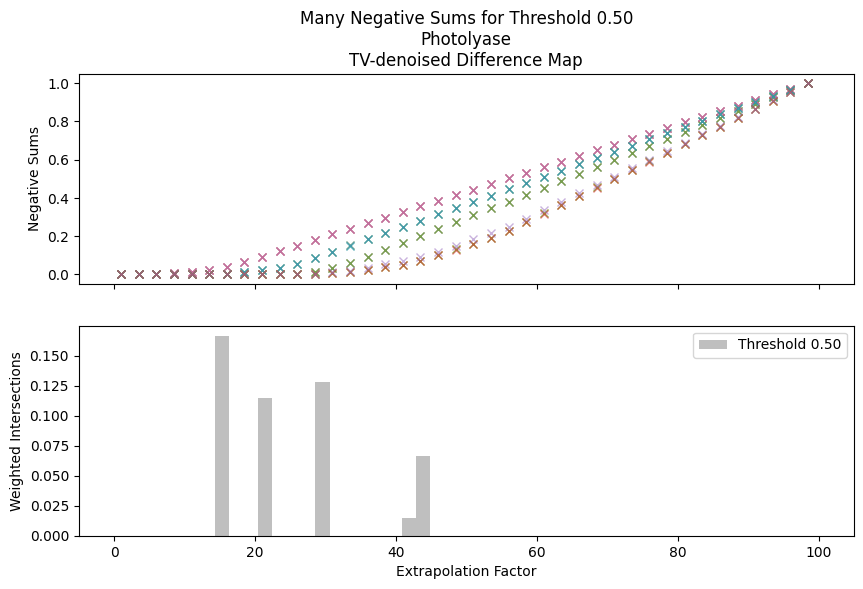

2025-07-28 16:23:48,777: INFO: Running Single NegSum (<string>:61)
/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/systematic_plots.py:176: RuntimeWarning: invalid value encountered in divide
  negsum = negsum / np.min(negsum)


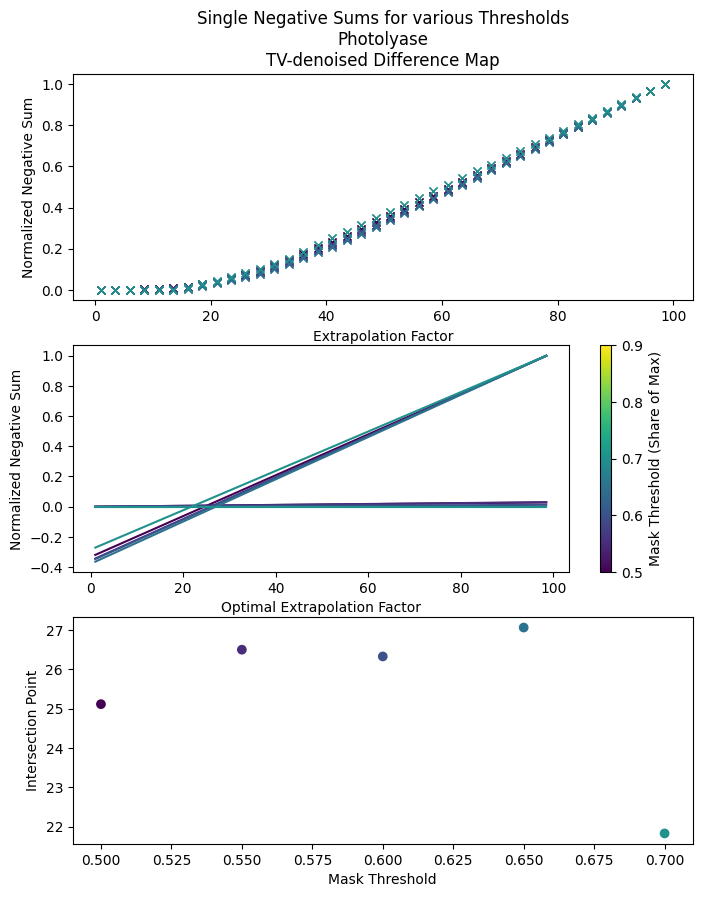

2025-07-28 16:24:02,457: INFO: Running Histogram Best Guess (<string>:65)
2025-07-28 16:24:03,789: INFO: len(dens_xtrs)=40, len(map_xtrs)=40 (systematic_plots.py:444)
2025-07-28 16:24:03,821: INFO: len_dens=40, len(bins)=100 (systematic_plots.py:451)


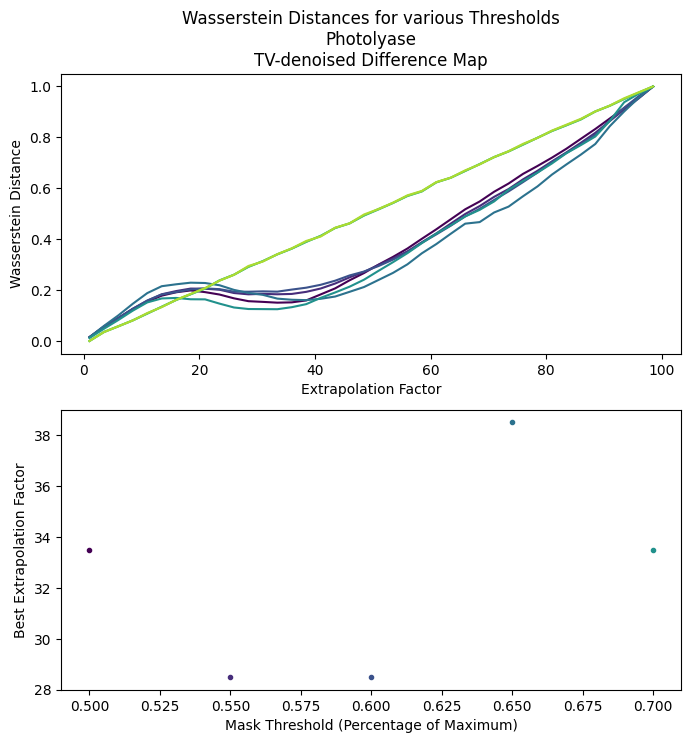

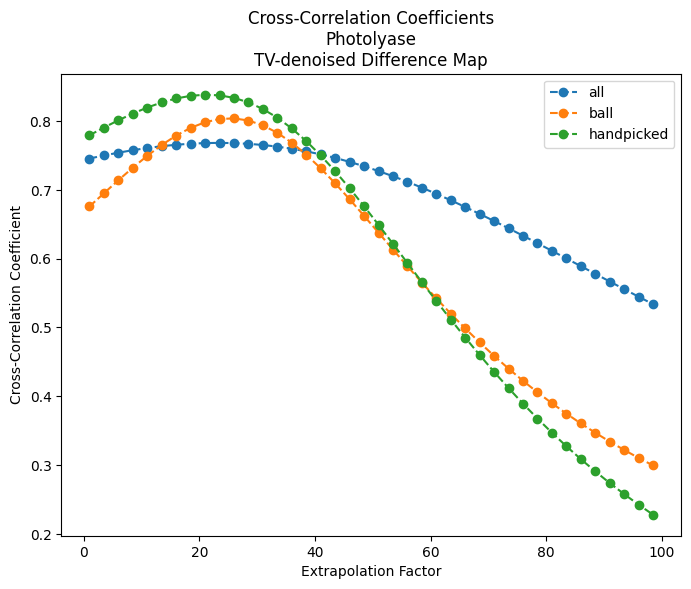

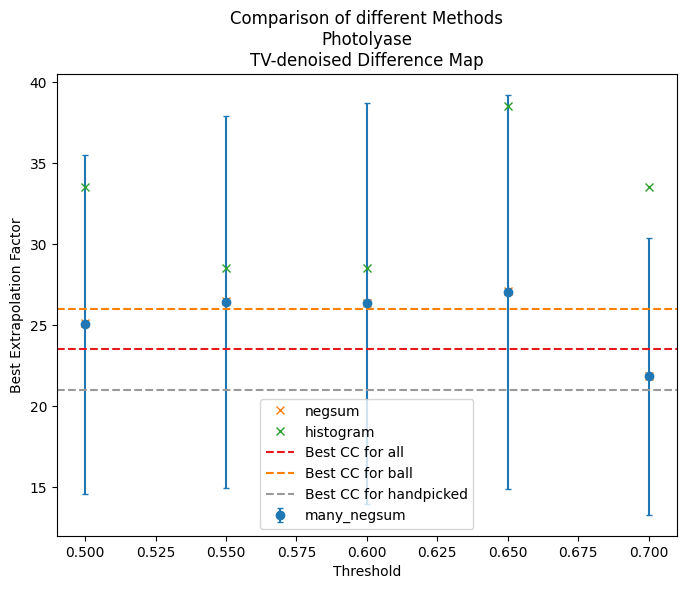

In [ ]:
from systematic_plots import run_plots
rho_shape = diffmap.to_3d_numpy_map(map_sampling=map_sampling).shape
info_container = {
    "tname": "Photolyase",
    "fname": changing_bit,
    "pdbloc_light": pdbloc_light,
    "hs_limit": hs_limit,
    "masks": {
        "ball": ccp4_to_mask(mask_loc_sphere, rho_shape),
        "handpicked": ccp4_to_mask(mask_loc_handcraft, rho_shape),
    },
    "diffmap_config": diffmap_config,
    "fshort": "PL",
    "minimum_threshold": 0.5
}
# diffmap_path = evaluation_path_basis + f"{key}/"
filestart = f"{info_container['fshort']}_{key}_"

filename_dict = {
            "save_fig": False,
            "display": True,
            "filestart": filestart,
            "rerun": True
            }

run_plots(diffmap, map_dark, info_container, key, filename_dict,)

In [11]:
2 or 1

2